# Imports

Dask config settings

In [1]:
import dask

In [2]:
# dask.config.set({"array.rechunk.method": "p2p"})

In [3]:
from pySVA.sva_core import *
from pySVA.sva_calc import *

ERROR 1: PROJ: proj_create_from_database: Open of /home/mgeraeds/.conda/envs/dfm_geo_clone1/share/proj failed


In [4]:
from pySVA.sva_helpers import *

In [5]:
import numpy as np

In [6]:
import dfm_tools as dfmt
import numpy as np
import xarray as xr

In [7]:
import pandas as pd

# Data description

In [8]:
# data_description = {
#     "nfaces": "mesh2d_nFaces",
#     "depth": "mesh2d_nLayers",
#     "time" : "time"
# }

data_description = {
    "flow_area": "mesh2d_au",
    "volume": "mesh2d_vol1",
    "velx" : "mesh2d_ucx",
    "vely" : "mesh2d_ucy",
    "velz" : "mesh2d_ucz",
    "viscosity" : "mesh2d_vicwwu",
    "tracer" : "mesh2d_sa1",
    "depth": "mesh2d_flowelem_zcc",
    "interfaces": "mesh2d_flowelem_zw"
}

# Set up dask cluster

In [9]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

In [10]:
n_cores = 48 #96
# n_processes = 96
# n_workers = n_cores/n_processes
mem_lim = str(336) + 'GB' #str(336)+'GB' # str(int(np.floor(336/(n_workers))))+'GB' # 336 for genoa # 224 for rome #n_cores*

In [11]:
cluster = SLURMCluster(name='dask-cluster',
                       cores=n_cores,
                       memory=mem_lim,
                       interface='ib0',
                       queue='genoa',
                       walltime='04:00:00',
                       asynchronous=0)

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39149 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: tcp://172.22.59.208:42131
INFO:distributed.scheduler:  dashboard at:  http://172.22.59.208:39149/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.scheduler:Receive client connection: Client-d29eff13-6c4c-11ef-aae9-3a7c767cabcb
INFO:distributed.core:Starting established connection to tcp://172.22.59.208:56884
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.235:37745', name: dask-cluster-0-1, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:

Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x14b8516af560>, (('rechunk-split-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 3, 2),), {})
new run_spec: (<function execute_task at 0x14b8516af560>, (('rechunk-split-transpose-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 3, 2),), {})
old token: ('tuple', [('913ceb5b5beb463a9010ec0790bc30002ca34164', []), ('tuple', [('tuple', ['rechunk-split-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 3, 2])]), ('dict', [])])
new token: ('tuple', [('913ceb5b5beb463a9010ec0790bc30002ca34164', []), ('tuple', [('tuple', ['rechunk-split-transpose-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 3, 2])]), ('dict', [])])
old dependencies: {('rechunk-split-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 3, 2)}
new dependencies: {('rechunk-split-transpose-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 3, 2)}

INFO:distributed.utils_perf:full garbage c

Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x14b8516af560>, (('rechunk-split-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 10, 2),), {})
new run_spec: (<function execute_task at 0x14b8516af560>, (('rechunk-split-transpose-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 10, 2),), {})
old token: ('tuple', [('913ceb5b5beb463a9010ec0790bc30002ca34164', []), ('tuple', [('tuple', ['rechunk-split-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 10, 2])]), ('dict', [])])
new token: ('tuple', [('913ceb5b5beb463a9010ec0790bc30002ca34164', []), ('tuple', [('tuple', ['rechunk-split-transpose-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 10, 2])]), ('dict', [])])
old dependencies: {('rechunk-split-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 10, 2)}
new dependencies: {('rechunk-split-transpose-rechunk-merge-d278f16bfbf6e70d80996547155abd03', 2, 0, 10, 2)}

Debugging information
--------------

In [12]:
print(cluster.job_script())

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p genoa
#SBATCH -n 1
#SBATCH --cpus-per-task=48
#SBATCH --mem=313G
#SBATCH -t 04:00:00

/home/mgeraeds/.conda/envs/dfm_geo_clone1/bin/python -m distributed.cli.dask_worker tcp://172.22.59.208:42131 --name dummy-name --nthreads 6 --memory-limit 39.12GiB --nworkers 8 --nanny --death-timeout 60 --interface ib0



In [13]:
cluster.scale(1)

In [14]:
client = Client(cluster)

In [15]:
client.dashboard_link

'http://172.22.59.208:39149/status'

In [16]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.22.59.208:39149/status,
Dashboard: http://172.22.59.208:39149/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.22.59.208:42131,Workers: 0
Dashboard: http://172.22.59.208:39149/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [17]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/00_RMM3d_2022_simulations/computations/B02_2022_jul21-aug7/B02_2022_jul21-aug7_sm/RMM_dflowfm_2022_jul21_aug7_sm_000*_map.nc'

# Load year and output reference

In [18]:
year = 2019

In [19]:
if year == 2019:
    folder = f"05_RMD_{year}"
elif year == 2022:
    folder = f"04_RMD_{year}"
    
output_dir = f'/projects/0/einf1300/saltis-wp3-1/D_Analysis/01_Simulations/{folder}/general'

# Load dataset

In [20]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/B04/B04_2022_jun23-24/ZUNO-zd_dflowfm_B04_jun23-24_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/C01/C01_jul30-31/RMD_dflowfm_C01_jul30-31_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/D02/D02_t1/RMD_dflowfm_D02_t1_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AU/RMD_dflowfm_D02AU_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AP/RMD_dflowfm_D02AP_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AU_newobs/RMD_dflowfm_D02AU_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D06/D06_16N/RMD_dflowfm_D06_16N_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D06/D06_19O/RMD_dflowfm_D06_19O_0000_map.nc'
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AU_newobs/RMD_dflowfm_D02AU_*_map.nc'

In [21]:
from functools import partial
def _preprocess(x, tstart, tend):
    return x.sel(time=slice(tstart, tend))

In [22]:
partial_func = partial(_preprocess, tstart=pd.to_datetime('2019-10-19 12:00'), tend=pd.to_datetime('2019-10-20 13:00'))

In [23]:
data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_*_"), chunks={'time':4}, preprocess=partial_func)# "mesh2d_nFaces":50000, "mesh2d_nNodes":50000, "mesh2d_nEdges":50000})#, "mesh2d_nFaces":5000, "mesh2d_nNodes":5000, "mesh2d_nEdges":5000})

>> xu.open_dataset() with 96 partition(s): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 : 135.81 sec
>> xu.merge_partitions() with 96 partition(s): 3.08 sec
>> some variables dropped with merging of partitions: ['mesh2d_face_x_bnd', 'mesh2d_face_y_bnd']
>> dfmt.open_partitioned_dataset() total: 138.91 sec


In [24]:
# data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_*_"), chunks={'time':4})

In [25]:
# test_ds = xr.open_mfdataset(r'/projects/0/einf1300/saltis-wp3-1/D_Analysis/01_Simulations/05_RMD_2019/D02AU_timing_test/cores_48/*', parallel=True, combine='nested', concat_dim='time', chunks={'time':12})
# test_ds['mesh2d_face_nodes'] = test_ds['mesh2d_face_nodes'].mean(dim='time')
# test_ds['mesh2d_edge_nodes'] = test_ds['mesh2d_edge_nodes'].mean(dim='time')
# # grid = xu.Ugrid2d.from_dataset(test_ds)
# new_test_ds = xu.core.wrap.UgridDataset(test_ds)
# uds = new_test_ds

In [26]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/D_Analysis/01_Simulations/05_RMD_2019/D0213AU_red_ts/*'
# data_xr_t = xr.open_mfdataset(glob.glob(file_nc), parallel=True, combine='nested', concat_dim='time')

In [27]:
uds = data_xr #.sel(time=slice('2019-08-01 00:00', '2019-08-31 23:00'))#.rolling(time=12, center=True).mean()?

In [28]:
uds.ugrid.set_crs("EPSG:28992")
uds = uds.ugrid.to_crs('WGS84')

In [29]:
gridname = uds.grid.name

In [30]:
uds.ugrid.crs[f'{gridname}'].name == 'WGS 84'

True

In [31]:
# uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_flowelem_bl'] < 0, np.nan)

In [32]:
# uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_sa1'] < 35, np.nan)
# 

In [33]:
import xugrid as xu
import matplotlib.pyplot as plt

In [34]:
uds = uds[["mesh2d_au","mesh2d_s1","mesh2d_vol1","mesh2d_ucx","mesh2d_ucy","mesh2d_ucz","mesh2d_vicwwu","mesh2d_sa1","mesh2d_flowelem_zcc","mesh2d_flowelem_zw", "mesh2d_node_z"]]

In [35]:
sva_obj = constructorSVA(uds, data_description)

In [36]:
from dfmproc.utils.plotting import GeneralPlot, plot_basic_background

In [37]:
import cmocean.cm as cmo
import cmestuary.cm as cme

In [38]:
dimn_cart = f'mesh2d_nCartesian_coords'

In [39]:
# bool_drycells = (uds['mesh2d_s1'] - uds['mesh2d_flowelem_bl']) < 0.25 # 0.0001 # standard EPSHU #other option: 0.0025
# # bool_drycells = (uds['mesh2d_flowelem_bl'] > 0)

In [40]:
import matplotlib as mpl

In [41]:
advection = sva_obj.advection

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  return func(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(sha

In [42]:
ucx_grad = sva_obj.compute_gradient_on_face(sva_obj.velx).persist()
ucy_grad = sva_obj.compute_gradient_on_face(sva_obj.vely).persist()

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  return func(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(sha

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 54.47 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [43]:
div = ucy_grad.isel(mesh2d_nCartesian_coords=1) + ucx_grad.isel(mesh2d_nCartesian_coords=0)

In [44]:
from dfmproc.utils.coordtransform import rd2latlon

In [45]:
hoek_location = (67926.26192321768, 443960.8904017157)
hoek_location = rd2latlon(hoek_location[0], hoek_location[1])

In [46]:
hoek_location

(51.97722216588492, 4.119836519845006)

In [47]:
wl = sva_obj.ds.ugrid.sel(y=hoek_location[0], x=hoek_location[1]).mesh2d_s1

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


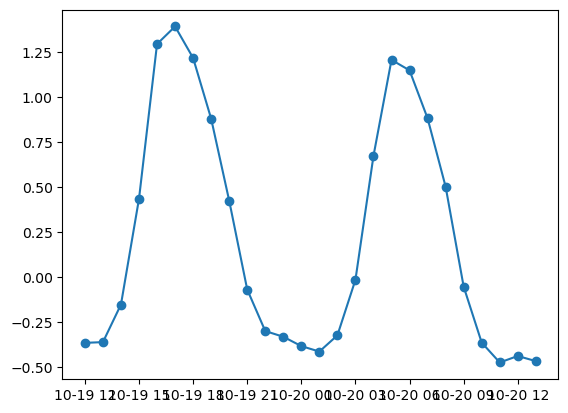

In [48]:
plt.plot(wl.time, wl)
plt.scatter(wl.time, wl)

In [49]:
from pySVA.sva_helpers import integrate_trapz

In [50]:
salinity_variance = sva_obj.tracer_variance

In [51]:
depth_integrated_salinity_variance = integrate_trapz(salinity_variance, sva_obj.depth.drop_vars([n for n,v in sva_obj.depth.coords.items() if f"{sva_obj.dimn_layer}" in v.dims]), dim=sva_obj.dimn_layer).rename(f"depth_integrated_{sva_obj.tracer.name}_variance")

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 551.06 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [52]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

In [53]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [54]:
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

In [55]:
import os

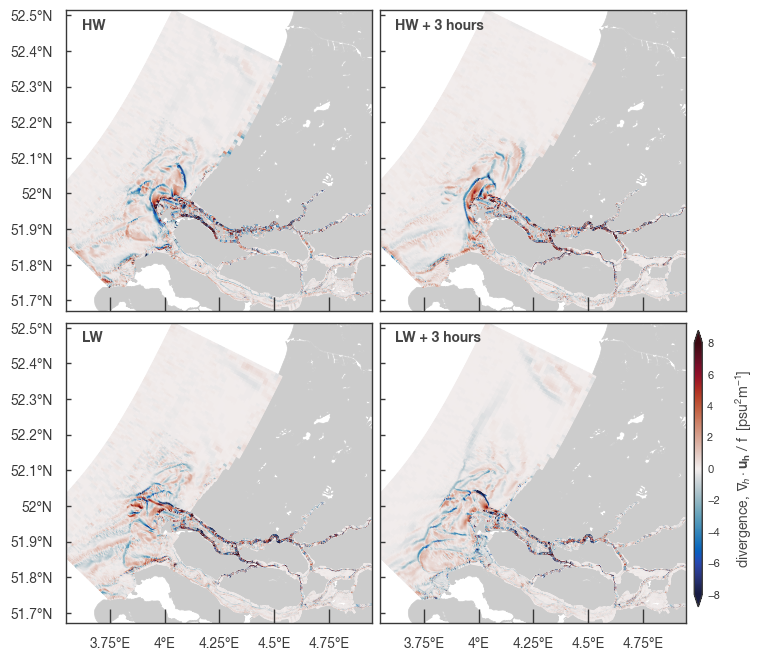

In [56]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [4, 7, 12, 15]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
    pc = (div/f).isel(mesh2d_nLayers=35, time=t).ugrid.plot(ax=ax, vmin=-8, vmax=8, cmap=cmo.balance, add_labels=False, add_colorbar=False)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
#     ax.set_title(f'HW + {t} hours')
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)

# add colorbar
# cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0 + 0.02, 0.005, axs[-1].get_position().height - 0.2])
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0 + 0.02, 0.01, axs[-1].get_position().height])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"divergence, $\nabla_h \cdot \mathbf{u_h}$ / f  [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=8) 
plt.subplots_adjust(wspace=0.025, hspace=0.03)

# add inset ax
# inset_ax = inset_axes(ax, width="30%", height=0.65, loc="upper right", borderpad=1)
# inset_ax.plot(np.arange(0, len(wl.time)), wl)
# inset_ax.scatter(t, wl.isel(time=t))
# inset_ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
# inset_ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
# inset_ax.set_xlabel('hours after LW', fontsize=8, labelpad=0.5)
# inset_ax.set_ylabel('$H$ [m + NAP]', fontsize=8, labelpad=0.5)
# inset_ax.tick_params(
#     axis='both',       # changes apply to the both axes
#     which='both',      # both major and minor ticks are affected
#     left=True,
#     bottom=True,      # ticks along the bottom edge are off
#     top=False,    
#     right=False,      # ticks along the top edge are off
#     labelbottom=True,
#     labelsize=8)

plt.savefig(os.path.join(output_dir, f'divergence_16N_D06_2019.png'), transparent=True)

In [57]:
import gc

In [58]:
gc.collect()

INFO:distributed.utils_perf:full garbage collection released 88.00 MiB from 2402 reference cycles (threshold: 9.54 MiB)


2402

Calculate terms and then rolling average them.

First calculate the tendency from the not tidally averaged `uds`

In [59]:
tendency = sva_obj.tendency

In [60]:
# tendency_st = tendency.rolling(dim={"time":12}).mean().mean(dim='time')

Change the `sva_obj` to the tidally averaged `uds`

In [61]:
# uds = uds.rolling(dim={"time":12}).mean()
# sva_obj = constructorSVA(xu.UgridDataset(uds, grids=data_xr.ugrid.grid), data_description)

Calculate the advection, straining, and dissipation on the full uds

In [62]:
straining = sva_obj.straining

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  return func(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(sha

In [63]:
gc.collect()

222

In [64]:
import matplotlib.colors as mcolors

In [65]:
straining = straining.chunk({"time":4})

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 56.75 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 56.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 56.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 56.75 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using fu

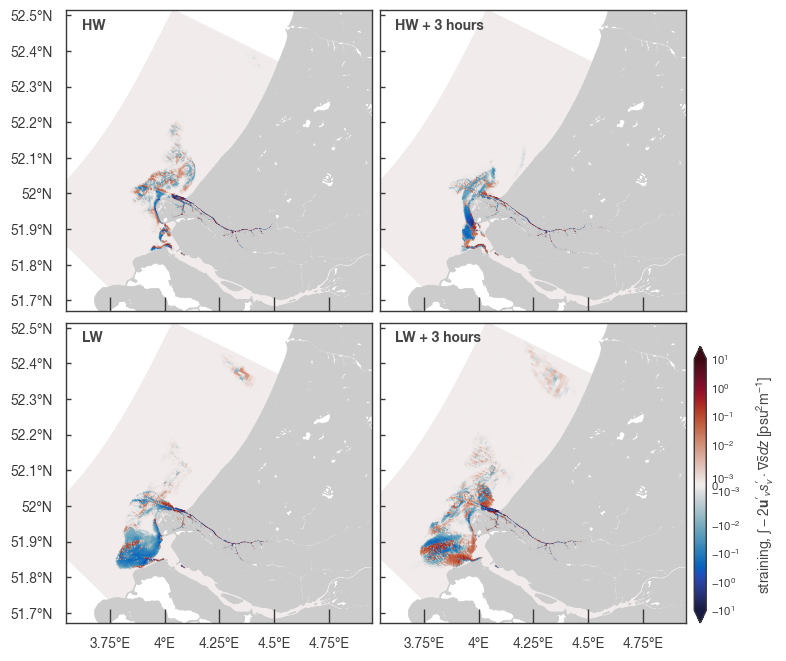

In [66]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [5, 8, 13, 16]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (straining).isel(time=t).ugrid.plot(ax=ax, cmap=cmo.balance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-3), vmin=-10, vmax=10, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
#     ax.set_title(f'LW + {t} hours')
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)


# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"straining, $\int -2\mathbf{u}'_{v} s_{v}' \cdot \nabla \bar{s} dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=8) 

plt.subplots_adjust(wspace=0.025, hspace=0.03)
plt.savefig(os.path.join(output_dir, f'straining_19O_D06_2019.png'), transparent=True)

In [67]:
# straining = straining.rolling(dim={"time":12}).mean()

In [68]:
dissipation = sva_obj.dissipation

edge-to-face interpolation: 0.20 sec


/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  return func(*args, **kwargs)


In [69]:
# dissipation = dissipation.rolling(dim={"time":12}).mean()

In [70]:
import cmasher as cmr

In [71]:
dissipation_cmap = cmr.get_sub_cmap(cmo.balance_r, 0,0.5)

In [72]:
import os

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 17.67 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
INFO:distributed.utils_perf:full garbage collection released 198.94 MiB from 535600 reference cycles (threshold: 9.54 MiB)
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 17.67 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 17.67 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarnin

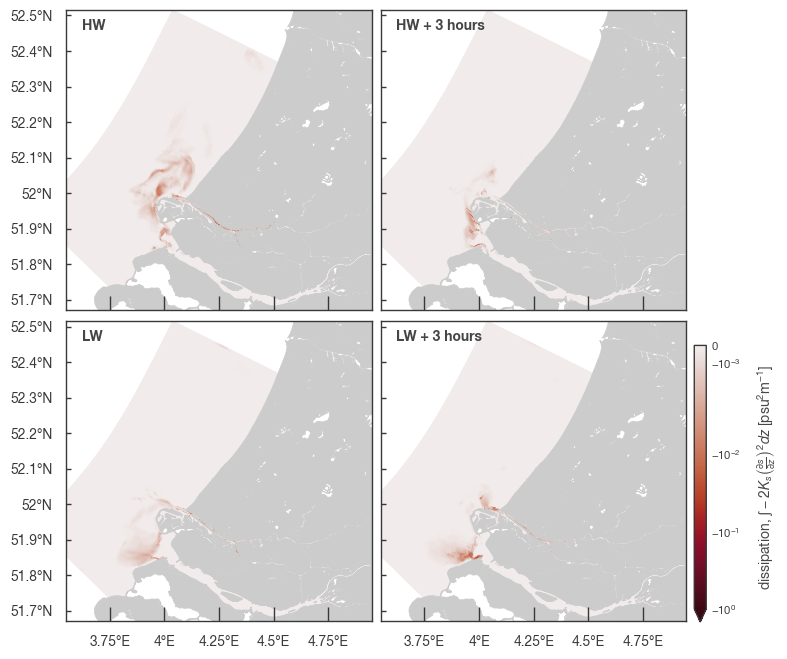

In [73]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [5, 8, 13, 16]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (dissipation).isel(time=t).ugrid.plot(ax=ax, cmap=dissipation_cmap, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-3), vmin=-1, vmax=0, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
#     ax.set_title(f'LW + {t} hours')
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)


# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
cax.tick_params(axis=u'both', which=u'both', length=0.1)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='min')
tracer_string = r"dissipation, $\int -2K_s \left(\frac{\partial s}{\partial z}\right)^2 dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=8) 

plt.subplots_adjust(wspace=0.03, hspace=0.02)

plt.savefig(os.path.join(output_dir, f'dissipation_D06_19O.png'), transparent=True)

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 65.62 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 65.62 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 65.50 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 65.62 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using fu

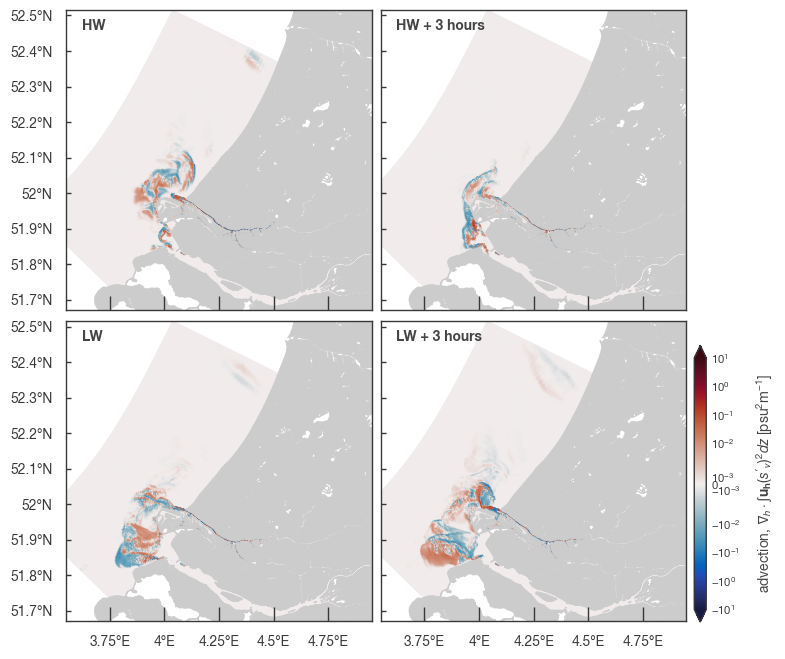

In [74]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [5, 8, 13, 16]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (advection).isel(time=t).ugrid.plot(ax=ax, cmap=cmo.balance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-3), vmin=-10, vmax=10, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
#     ax.set_title(f'LW + {t} hours')
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)


# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
cax.tick_params(axis=u'both', which=u'both', length=0.1)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"advection, $\nabla_h \cdot \int\mathbf{u_h}(s'_{v})^2 dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=8) 

plt.subplots_adjust(wspace=0.03, hspace=0.02)

plt.savefig(os.path.join(output_dir, f'advection_D06_19O.png'), transparent=True)

In [75]:
tendency = sva_obj.tendency

In [76]:
import matplotlib.colors as mcolors
import os

INFO:distributed.utils_perf:full garbage collection released 167.50 MiB from 539738 reference cycles (threshold: 9.54 MiB)


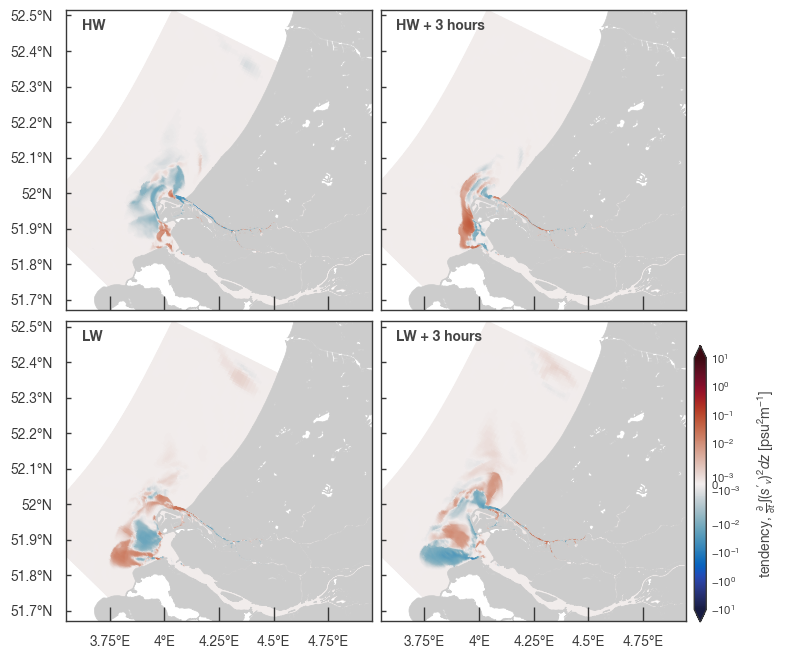

In [77]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [5, 8, 13, 16]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (tendency).isel(time=t).ugrid.plot(ax=ax, cmap=cmo.balance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-3), vmin=-10, vmax=10, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
#     ax.set_title(f'LW + {t} hours')
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)


# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
cax.tick_params(axis=u'both', which=u'both', length=0.1)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"tendency, $\frac{\partial}{\partial t}\int(s'_{v})^2dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=8) 

plt.subplots_adjust(wspace=0.03, hspace=0.02)

plt.savefig(os.path.join(output_dir, f'tendency_D06_16N.png'), transparent=True)

In [79]:
numerical_dissipation = (tendency + advection - straining + dissipation)*-1

INFO:distributed.utils_perf:full garbage collection released 98.90 MiB from 531649 reference cycles (threshold: 9.54 MiB)
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 84.69 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 84.85 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 84.79 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning

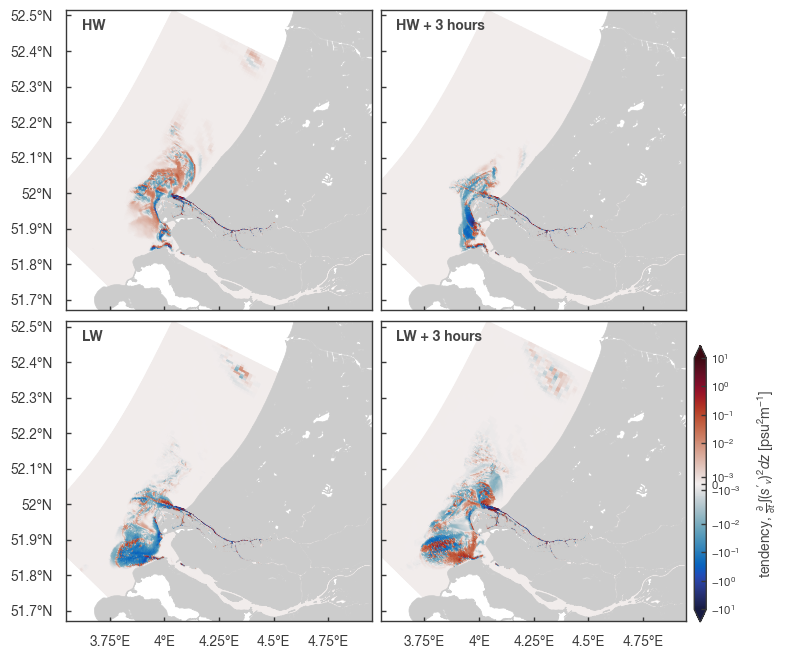

In [93]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [5, 8, 13, 16]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (numerical_dissipation).isel(time=t).ugrid.plot(ax=ax, cmap=cmo.balance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-3), vmin=-10, vmax=10, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)
    ax.set_xlim(3.55, 4.95)
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', length=3)

# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
# cax.tick_params(axis=u'both', which=u'both', length=0.1)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"tendency, $\frac{\partial}{\partial t}\int(s'_{v})^2dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=8) 

plt.subplots_adjust(wspace=0.03, hspace=0.02)

plt.savefig(os.path.join(output_dir, f'num_dissipation_D06_19O.png'), transparent=True)

In [82]:
depth_integrated_tracer_variance = sva_obj.depth_integrated_tracer_variance

/home/mgeraeds/.conda/envs/dfm_geo_clone1/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 551.06 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


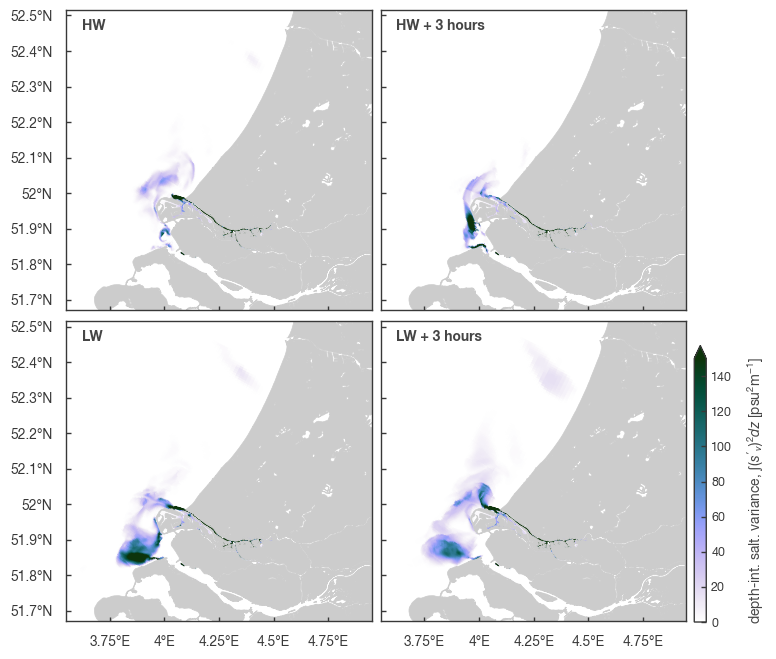

In [92]:
fig, axs = plt.subplots(2,2, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [5, 8, 13, 16]
plot_times = ['HW', 'HW + 3 hours', 'LW', 'LW + 3 hours']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (depth_integrated_tracer_variance).isel(time=t).ugrid.plot(ax=ax, cmap=cmr.horizon_r, add_labels=False, add_colorbar=False, vmin=0, vmax=150, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

    ax.set_xlim(3.55, 4.95)
#     ax.set_title(f'LW + {t} hours')
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', length=3)

# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
# cax.tick_params(axis=u'both', which=u'both', length=1)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='max')
tracer_string = r"depth-int. salt. variance, $\int(s'_{v})^2dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 

plt.subplots_adjust(wspace=0.03, hspace=0.02)

plt.savefig(os.path.join(output_dir, f'depth_int_sa_var_D06_19O.png'), transparent=True)

INFO:distributed.utils_perf:full garbage collection released 21.98 MiB from 402711 reference cycles (threshold: 9.54 MiB)


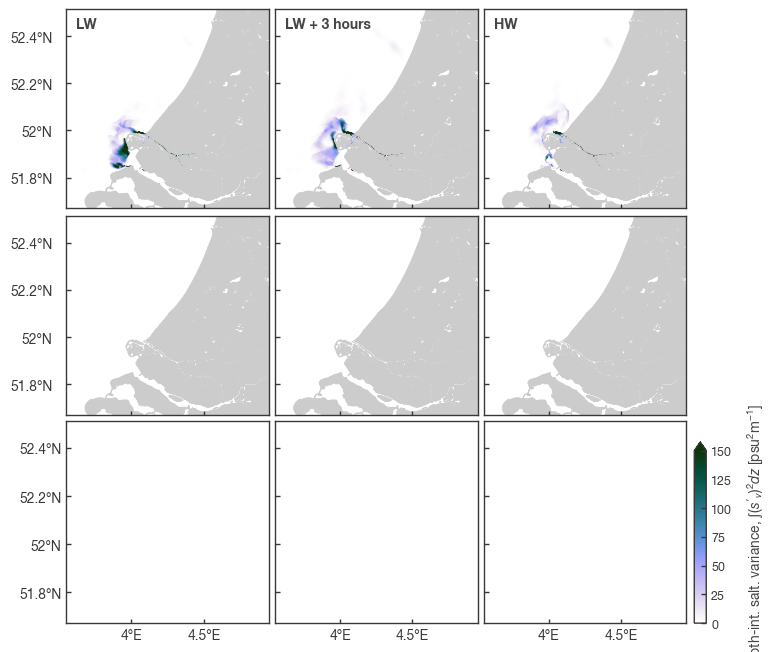

In [96]:
fig, axs = plt.subplots(3,3, FigureClass=GeneralPlot, figsize=(8,8), sharey=True, sharex=True)
times = [0, 3, 5]
plot_times = ['LW', 'LW + 3 hours', 'HW']
axs = axs.flatten()

for t, p_t, ax in zip(times, plot_times, axs[0:3]):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    pc = (depth_integrated_tracer_variance).isel(time=t).ugrid.plot(ax=ax, cmap=cmr.horizon_r, add_labels=False, add_colorbar=False, vmin=0, vmax=150, zorder=0)
    # pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)
    ax.set_title(f'{p_t}', x=0.05, y=1.0, pad=-14, loc='left', fontweight='bold', fontsize=10)
    
for t, ax in zip(times, axs[3:7]):
    bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
    
for ax in axs:
    ax.set_xlim(3.55, 4.95)
    ax.tick_params(axis='x', length=3)
    
# add colorbar
cax = fig.add_axes([axs[-1].get_position().x1 + 0.01, axs[-1].get_position().y0, 0.015, axs[-1].get_position().height])
# cax.tick_params(axis=u'both', which=u'both', length=1)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='max')
tracer_string = r"depth-int. salt. variance, $\int(s'_{v})^2dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 

plt.subplots_adjust(wspace=0.03, hspace=0.02)

# plt.savefig(os.path.join(output_dir, f'depth_int_sa_var_D06_19O.png'), transparent=True)

In [ ]:
from matplotlib import ticker

In [ ]:
cmap_sub = cmr.get_sub_cmap(cme.variance, 0, 0.5)

In [ ]:
gradient = sva_obj.compute_gradient_on_face(sva_obj.tracer)

In [ ]:
salinity_gradient = np.sqrt(gradient.isel({dimn_cart:0})**2 + gradient.isel({dimn_cart:1})**2)

In [ ]:
uds['mesh2d_grad_sa1'] = salinity_gradient

In [ ]:
surface_uds = dfmt.get_Dataset_atdepths(uds, depths=-0.1, reference='waterlevel')

In [ ]:
# plot_surface_grad.isel(time=2).ugrid.plot(add_labels=False, vmax=5, zorder=0)

In [ ]:
sva_obj.ds.mesh2d_sa1.isel(mesh2d_nLayers=30, time=2).ugrid.plot(add_labels=False, add_colorbar=False, vmax=35, zorder=0)